# 🎮 Regional Sales Breakdown and Genre Trends in Video Game Market

**Level:** Intermediate

**Objective:** Analyze global video game sales data to understand which platforms, genres and publishers dominate different regional markets and how the industry evolved over time.

**Tools:** pandas, matplotlib, seaborn

---

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

print('\u2705 Libraries imported successfully')

✅ Libraries imported successfully


In [2]:
df = pd.read_csv('vgsales.csv')
print(f'Dataset shape: {df.shape[0]:,} rows \u00d7 {df.shape[1]} columns')
print(f'\nColumns:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:>2}. {col:<15} ({df[col].dtype})')
df.head()

Dataset shape: 16,598 rows × 11 columns

Columns:
   1. Rank            (int64)
   2. Name            (object)
   3. Platform        (object)
   4. Year            (float64)
   5. Genre           (object)
   6. Publisher       (object)
   7. NA_Sales        (float64)
   8. EU_Sales        (float64)
   9. JP_Sales        (float64)
  10. Other_Sales     (float64)
  11. Global_Sales    (float64)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## 2. Data Quality Check & Cleaning

In [3]:
print('='*60)
print('MISSING VALUES (Before Cleaning)')
print('='*60)
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

# Handle missing values
print('\n' + '='*60)
print('CLEANING')
print('='*60)

# Drop rows where Year is NaN
before = len(df)
df = df.dropna(subset=['Year'])
df['Year'] = df['Year'].astype(int)
print(f'Dropped {before - len(df)} rows with missing Year')

# Fill Publisher NaN with "Unknown"
df['Publisher'] = df['Publisher'].fillna('Unknown')
print(f'Filled Publisher NaN with "Unknown"')

print(f'\n\u2705 Clean dataset: {len(df):,} rows \u00d7 {df.shape[1]} columns')
print(f'Remaining missing: {df.isnull().sum().sum()}')

MISSING VALUES (Before Cleaning)
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

Total missing: 329

CLEANING
Dropped 271 rows with missing Year
Filled Publisher NaN with "Unknown"

✅ Clean dataset: 16,327 rows × 11 columns
Remaining missing: 0


In [4]:
print('DESCRIPTIVE STATISTICS (Sales in Millions)')
print('='*80)
df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].describe().round(2)

DESCRIPTIVE STATISTICS (Sales in Millions)


,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16327.00,16327.00,16327.00,16327.00,16327.00
mean,0.27,0.15,0.08,0.05,0.54
std,0.82,0.51,0.31,0.19,1.57
min,0.00,0.00,0.00,0.00,0.01
25%,0.00,0.00,0.00,0.00,0.06
50%,0.08,0.02,0.00,0.01,0.17
75%,0.24,0.11,0.04,0.04,0.48
max,41.49,29.02,10.22,10.57,82.74


## 3. Total Global Sales by Genre, Platform, Publisher (Top 10)

In [5]:
# --- 3.1 Sales by GENRE ---
genre_sales = df.groupby('Genre').agg(
    Global=('Global_Sales', 'sum'), NA=('NA_Sales', 'sum'),
    EU=('EU_Sales', 'sum'), JP=('JP_Sales', 'sum'),
    Game_Count=('Name', 'count')
).round(2).sort_values('Global', ascending=False)

genre_sales['Avg_per_Game'] = (genre_sales['Global'] / genre_sales['Game_Count']).round(2)

print('\U0001f3ae GLOBAL SALES BY GENRE (Millions)')
print('='*80)
genre_sales

🎮 GLOBAL SALES BY GENRE (Millions)


,Global,NA,EU,JP,Game_Count,Avg_per_Game
Genre,,,,,,
Action,1722.88,861.80,516.48,158.66,3253,0.53
Sports,1309.24,670.09,371.34,134.76,2304,0.57
Shooter,1026.20,575.16,310.45,38.18,1282,0.80
Role-Playing,923.84,326.50,187.58,350.29,1471,0.63
Platform,829.15,445.99,200.67,130.65,876,0.95
Misc,797.62,402.48,213.82,106.67,1710,0.47
Racing,726.77,356.93,236.32,56.61,1226,0.59
Fighting,444.05,220.74,100.00,87.15,836,0.53
Simulation,390.16,181.78,113.20,63.54,851,0.46


In [6]:
# --- 3.2 Top 10 PLATFORMS ---
platform_sales = df.groupby('Platform')['Global_Sales'].sum().round(2).sort_values(ascending=False).head(10)

print('\U0001f3ae TOP 10 PLATFORMS BY GLOBAL SALES (Millions)')
print('='*60)
for i, (plat, val) in enumerate(platform_sales.items(), 1):
    print(f'  {i:>2}. {plat:<10} ${val:>8,.2f}M')

🎮 TOP 10 PLATFORMS BY GLOBAL SALES (Millions)
   1. PS2        $1,233.46M
   2. X360       $  969.61M
   3. PS3        $  949.35M
   4. Wii        $  909.81M
   5. DS         $  818.96M
   6. PS         $  727.39M
   7. GBA        $  313.56M
   8. PSP        $  291.71M
   9. PS4        $  278.10M
  10. PC         $  255.05M


In [7]:
# --- 3.3 Top 10 PUBLISHERS ---
pub_sales = df.groupby('Publisher')['Global_Sales'].sum().round(2).sort_values(ascending=False).head(10)

print('\U0001f3ae TOP 10 PUBLISHERS BY GLOBAL SALES (Millions)')
print('='*60)
for i, (pub, val) in enumerate(pub_sales.items(), 1):
    marker = '\U0001f947' if i == 1 else ('\U0001f948' if i == 2 else ('\U0001f949' if i == 3 else '  '))
    print(f'{marker} {i:>2}. {pub:<30} ${val:>8,.2f}M')

🎮 TOP 10 PUBLISHERS BY GLOBAL SALES (Millions)
🥇  1. Nintendo                       $1,784.43M
🥈  2. Electronic Arts                $1,093.39M
🥉  3. Activision                     $  721.41M
    4. Sony Computer Entertainment    $  607.28M
    5. Ubisoft                        $  473.54M
    6. Take-Two Interactive           $  399.30M
    7. THQ                            $  340.44M
    8. Konami Digital Entertainment   $  278.56M
    9. Sega                           $  270.70M
   10. Namco Bandai Games             $  253.65M


## 4. Regional Sales Share: NA vs EU vs JP as % of Global

In [8]:
# Overall regional share
total_global = df['Global_Sales'].sum()
total_na = df['NA_Sales'].sum()
total_eu = df['EU_Sales'].sum()
total_jp = df['JP_Sales'].sum()
total_other = df['Other_Sales'].sum()

print('\U0001f30d REGIONAL SALES SHARE')
print('='*50)
print(f'  NA (North America):  ${total_na:>8,.2f}M  ({total_na/total_global*100:.1f}%)')
print(f'  EU (Europe):         ${total_eu:>8,.2f}M  ({total_eu/total_global*100:.1f}%)')
print(f'  JP (Japan):          ${total_jp:>8,.2f}M  ({total_jp/total_global*100:.1f}%)')
print(f'  Other:               ${total_other:>8,.2f}M  ({total_other/total_global*100:.1f}%)')
print(f'  \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500')
print(f'  Global Total:        ${total_global:>8,.2f}M')

🌍 REGIONAL SALES SHARE
  NA (North America):  $4,333.43M  (49.1%)
  EU (Europe):         $2,409.12M  (27.3%)
  JP (Japan):          $1,284.30M  (14.6%)
  Other:               $  789.01M  (8.9%)
  ────────────────────────
  Global Total:        $8,820.36M


In [9]:
# Regional share PER GENRE
regional_pct = pd.DataFrame()
regional_pct['NA_%'] = (genre_sales['NA'] / genre_sales['Global'] * 100).round(1)
regional_pct['EU_%'] = (genre_sales['EU'] / genre_sales['Global'] * 100).round(1)
regional_pct['JP_%'] = (genre_sales['JP'] / genre_sales['Global'] * 100).round(1)
regional_pct['Other_%'] = (100 - regional_pct['NA_%'] - regional_pct['EU_%'] - regional_pct['JP_%']).round(1)

print('\U0001f4ca REGIONAL SALES SHARE (%) PER GENRE')
print('='*60)
regional_pct

📊 REGIONAL SALES SHARE (%) PER GENRE


,NA_%,EU_%,JP_%,Other_%
Genre,,,,
Action,50.0,30.0,9.2,10.8
Sports,51.2,28.4,10.3,10.1
Shooter,56.0,30.3,3.7,10.0
Role-Playing,35.3,20.3,37.9,6.5
Platform,53.8,24.2,15.8,6.2
Misc,50.5,26.8,13.4,9.3
Racing,49.1,32.5,7.8,10.6
Fighting,49.7,22.5,19.6,8.2
Simulation,46.6,29.0,16.3,8.1


## 5. Most Popular Genre in Each Region

In [10]:
na_top = df.groupby('Genre')['NA_Sales'].sum().sort_values(ascending=False)
eu_top = df.groupby('Genre')['EU_Sales'].sum().sort_values(ascending=False)
jp_top = df.groupby('Genre')['JP_Sales'].sum().sort_values(ascending=False)

print('\U0001f3c6 MOST POPULAR GENRE BY REGION')
print('='*60)
print(f'  \U0001f1fa\U0001f1f8 NA: {na_top.index[0]:<20} (${na_top.iloc[0]:,.2f}M)')
print(f'  \U0001f1ea\U0001f1fa EU: {eu_top.index[0]:<20} (${eu_top.iloc[0]:,.2f}M)')
print(f'  \U0001f1ef\U0001f1f5 JP: {jp_top.index[0]:<20} (${jp_top.iloc[0]:,.2f}M)')

print(f'\n\U0001f4ca TOP 3 GENRES PER REGION')
print('='*60)
for region, data, flag in [('NA', na_top, '\U0001f1fa\U0001f1f8'), ('EU', eu_top, '\U0001f1ea\U0001f1fa'), ('JP', jp_top, '\U0001f1ef\U0001f1f5')]:
    print(f'\n{flag} {region}:')
    for i, (g, v) in enumerate(data.head(3).items(), 1):
        print(f'  {i}. {g:<20} ${v:,.2f}M')

🏆 MOST POPULAR GENRE BY REGION
  🇺🇸 NA: Action               ($861.80M)
  🇪🇺 EU: Action               ($516.48M)
  🇯🇵 JP: Role-Playing         ($350.29M)

📊 TOP 3 GENRES PER REGION

🇺🇸 NA:
  1. Action               $861.80M
  2. Sports               $670.09M
  3. Shooter              $575.16M

🇪🇺 EU:
  1. Action               $516.48M
  2. Sports               $371.34M
  3. Shooter              $310.45M

🇯🇵 JP:
  1. Role-Playing         $350.29M
  2. Action               $158.66M
  3. Sports               $134.76M


## 6. Yearly Global Sales Trend (1980\u20132016)

In [11]:
yearly = df.groupby('Year').agg(
    Global=('Global_Sales', 'sum'), NA=('NA_Sales', 'sum'),
    EU=('EU_Sales', 'sum'), JP=('JP_Sales', 'sum'),
    Game_Count=('Name', 'count')
).round(2)

yearly['Avg_Sales'] = (yearly['Global'] / yearly['Game_Count']).round(2)

print('\U0001f4c5 YEARLY SALES TREND (Top 10 Years)')
print('='*70)
yearly.sort_values('Global', ascending=False).head(10)

📅 YEARLY SALES TREND (Top 10 Years)


,Global,NA,EU,JP,Game_Count,Avg_Sales
Year,,,,,,
2008,678.90,351.44,184.40,60.26,1428,0.48
2009,667.30,338.85,191.59,61.89,1431,0.47
2007,611.13,312.05,160.50,60.29,1202,0.51
2010,600.45,304.24,176.73,59.49,1259,0.48
2006,521.04,263.12,129.24,73.73,1008,0.52
2011,515.99,241.06,167.44,53.04,1139,0.45
2005,459.94,242.61,121.94,54.28,941,0.49
2004,419.31,222.59,107.32,41.65,763,0.55
2002,395.52,216.19,109.74,41.76,829,0.48


## 7. Top 10 Best-Selling Games of All Time

In [12]:
top10_games = df.nsmallest(10, 'Rank')[['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'Global_Sales', 'NA_Sales', 'EU_Sales', 'JP_Sales']]

print('\U0001f3c6 TOP 10 BEST-SELLING GAMES OF ALL TIME')
print('='*100)
for _, row in top10_games.iterrows():
    print(f'  #{int(row["Rank"]):>2}  {row["Name"]:<35} | {row["Platform"]:<5} | {row["Genre"]:<15} | {row["Publisher"]:<15} | ${row["Global_Sales"]:>6.2f}M')

🏆 TOP 10 BEST-SELLING GAMES OF ALL TIME
  # 1  Wii Sports                          | Wii   | Sports          | Nintendo        | $ 82.74M
  # 2  Super Mario Bros.                   | NES   | Platform        | Nintendo        | $ 40.24M
  # 3  Mario Kart Wii                      | Wii   | Racing          | Nintendo        | $ 35.82M
  # 4  Wii Sports Resort                   | Wii   | Sports          | Nintendo        | $ 33.00M
  # 5  Pokemon Red/Pokemon Blue            | GB    | Role-Playing    | Nintendo        | $ 31.37M
  # 6  Tetris                              | GB    | Puzzle          | Nintendo        | $ 30.26M
  # 7  New Super Mario Bros.               | DS    | Platform        | Nintendo        | $ 30.01M
  # 8  Wii Play                            | Wii   | Misc            | Nintendo        | $ 29.02M
  # 9  New Super Mario Bros. Wii           | Wii   | Platform        | Nintendo        | $ 28.62M
  #10  Duck Hunt                           | NES   | Shooter         | Nintend

## 8. Visualizations

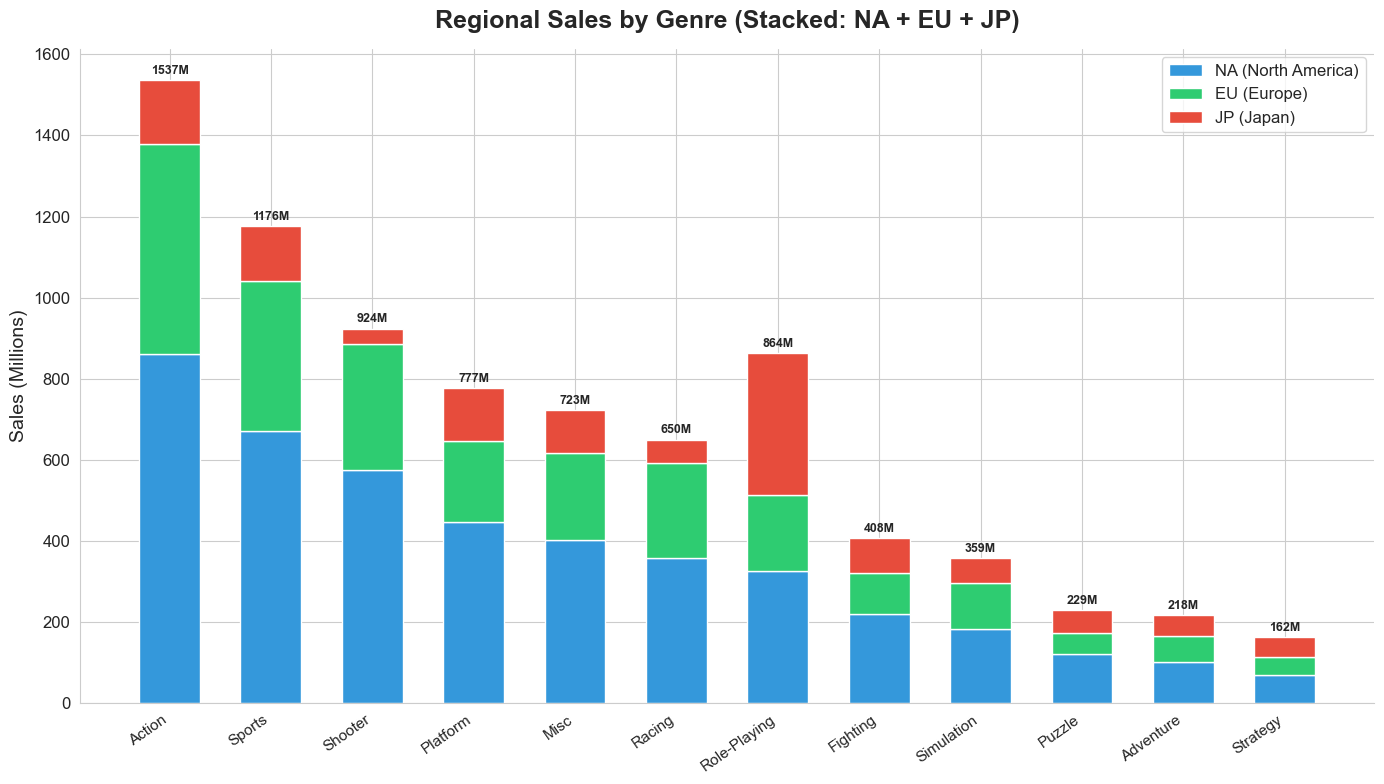

💾 Saved: chart1_stacked_regional_genre.png


In [13]:
# --- CHART 1: Stacked Bar --- Regional Sales by Genre ---
genre_regional = genre_sales[['NA', 'EU', 'JP']].sort_values('NA', ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
x = range(len(genre_regional))
w = 0.6

bars_na = ax.bar(x, genre_regional['NA'], w, color='#3498db', label='NA (North America)')
bars_eu = ax.bar(x, genre_regional['EU'], w, bottom=genre_regional['NA'], color='#2ecc71', label='EU (Europe)')
bars_jp = ax.bar(x, genre_regional['JP'], w, bottom=genre_regional['NA']+genre_regional['EU'], color='#e74c3c', label='JP (Japan)')

for i, (na, eu, jp) in enumerate(zip(genre_regional['NA'], genre_regional['EU'], genre_regional['JP'])):
    total = na + eu + jp
    ax.text(i, total + 15, f'{na+eu+jp:.0f}M', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(genre_regional.index, rotation=35, ha='right', fontsize=11)
ax.set_title('Regional Sales by Genre (Stacked: NA + EU + JP)', fontsize=18, fontweight='bold', pad=15)
ax.set_ylabel('Sales (Millions)', fontsize=14)
ax.legend(fontsize=12, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart1_stacked_regional_genre.png', dpi=150, bbox_inches='tight')
plt.show()
print('\U0001f4be Saved: chart1_stacked_regional_genre.png')

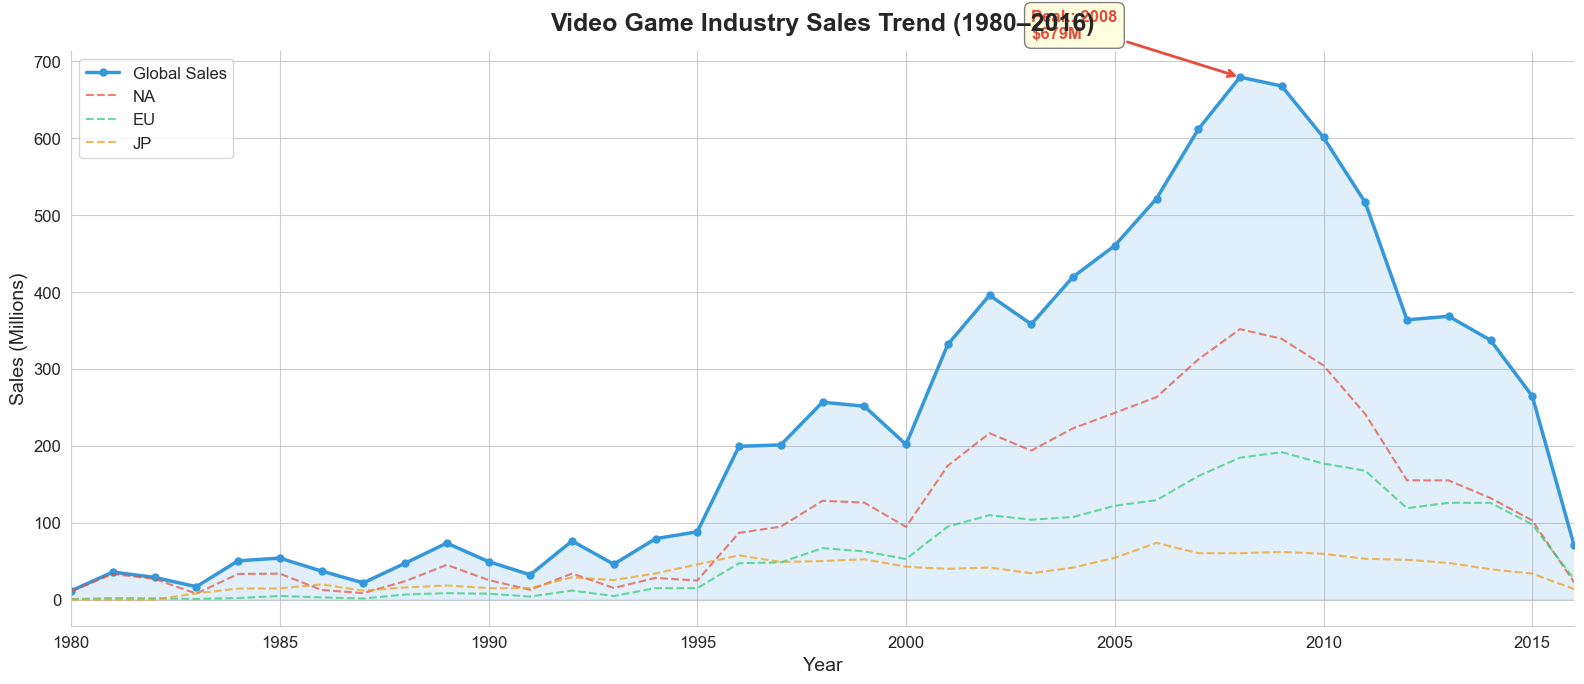

💾 Saved: chart2_yearly_trend.png


In [14]:
# --- CHART 2: Yearly Trend Line ---
fig, ax1 = plt.subplots(figsize=(16, 7))

years = yearly.index.astype(int)
ax1.fill_between(years, yearly['Global'], alpha=0.15, color='#3498db')
ax1.plot(years, yearly['Global'], marker='o', color='#3498db', linewidth=2.5, markersize=5, label='Global Sales')
ax1.plot(years, yearly['NA'], '--', color='#e74c3c', linewidth=1.5, alpha=0.7, label='NA')
ax1.plot(years, yearly['EU'], '--', color='#2ecc71', linewidth=1.5, alpha=0.7, label='EU')
ax1.plot(years, yearly['JP'], '--', color='#f39c12', linewidth=1.5, alpha=0.7, label='JP')

peak_year = yearly['Global'].idxmax()
peak_val = yearly['Global'].max()
ax1.annotate(f'Peak: {int(peak_year)}\n${peak_val:.0f}M', xy=(peak_year, peak_val),
            xytext=(peak_year-5, peak_val+50), fontsize=12, fontweight='bold', color='#e74c3c',
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=2),
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray'))

ax1.set_title('Video Game Industry Sales Trend (1980\u20132016)', fontsize=18, fontweight='bold', pad=15)
ax1.set_xlabel('Year', fontsize=14)
ax1.set_ylabel('Sales (Millions)', fontsize=14)
ax1.legend(fontsize=12, loc='upper left')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xlim(1980, 2016)

plt.tight_layout()
plt.savefig('chart2_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('\U0001f4be Saved: chart2_yearly_trend.png')

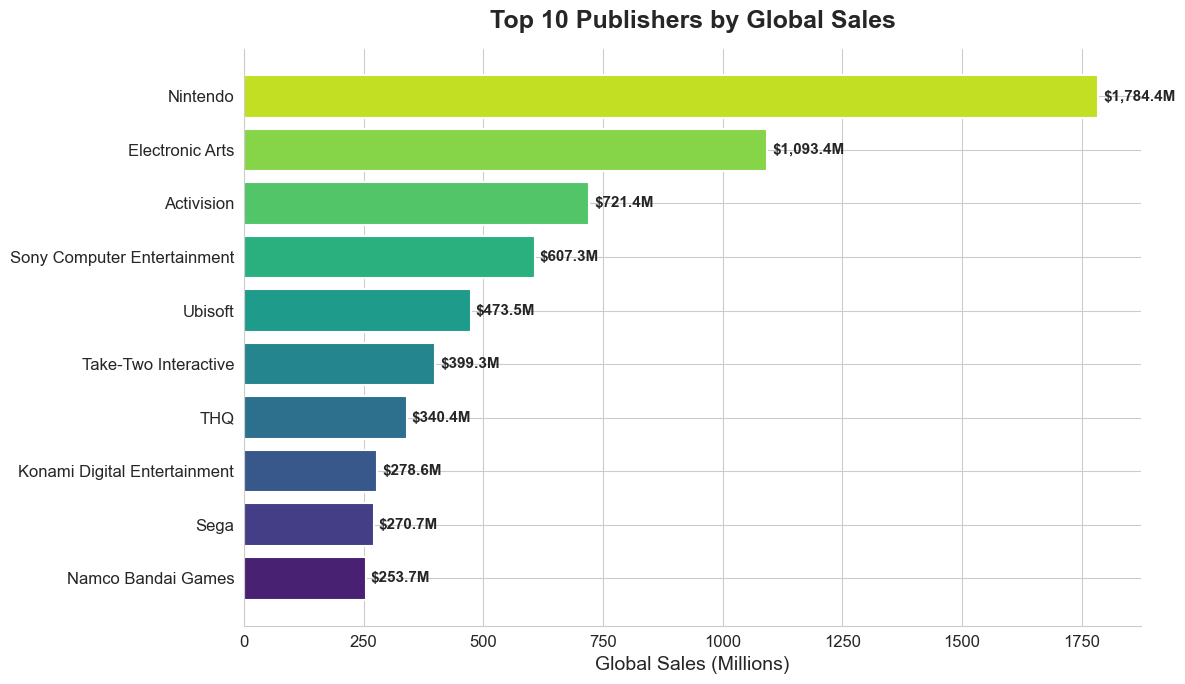

💾 Saved: chart3_top10_publishers.png


In [15]:
# --- CHART 3: Top 10 Publishers Bar Chart ---
fig, ax = plt.subplots(figsize=(12, 7))
pub_sorted = pub_sales.sort_values(ascending=True)
colors_pub = sns.color_palette('viridis', len(pub_sorted))

bars = ax.barh(pub_sorted.index, pub_sorted.values, color=colors_pub, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, pub_sorted.values):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'${val:,.1f}M', va='center', fontsize=11, fontweight='bold')

ax.set_title('Top 10 Publishers by Global Sales', fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Global Sales (Millions)', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart3_top10_publishers.png', dpi=150, bbox_inches='tight')
plt.show()
print('\U0001f4be Saved: chart3_top10_publishers.png')

## 9. \u2b50 Bonus Features

In [16]:
# --- BONUS 1: Decade with highest avg sales per game ---
def get_decade(year):
    if year < 1990: return '1980s'
    elif year < 2000: return '1990s'
    elif year < 2010: return '2000s'
    else: return '2010s'

df['Decade'] = df['Year'].apply(get_decade)

decade_analysis = df.groupby('Decade').agg(
    Total_Sales=('Global_Sales', 'sum'),
    Game_Count=('Name', 'count'),
    Avg_Sales=('Global_Sales', 'mean')
).round(3)

print('\u2b50 AVERAGE SALES PER GAME BY DECADE')
print('='*60)
for dec, row in decade_analysis.iterrows():
    bar = '\u2588' * int(row['Avg_Sales'] * 10)
    best = ' \U0001f3c6' if row['Avg_Sales'] == decade_analysis['Avg_Sales'].max() else ''
    print(f'  {dec}: ${row["Avg_Sales"]:.3f}M avg | {int(row["Game_Count"]):>5,} games | {bar}{best}')

⭐ AVERAGE SALES PER GAME BY DECADE
  1980s: $1.837M avg |   205 games | ██████████████████ 🏆
  1990s: $0.723M avg | 1,769 games | ███████
  2000s: $0.504M avg | 9,208 games | █████
  2010s: $0.490M avg | 5,145 games | ████


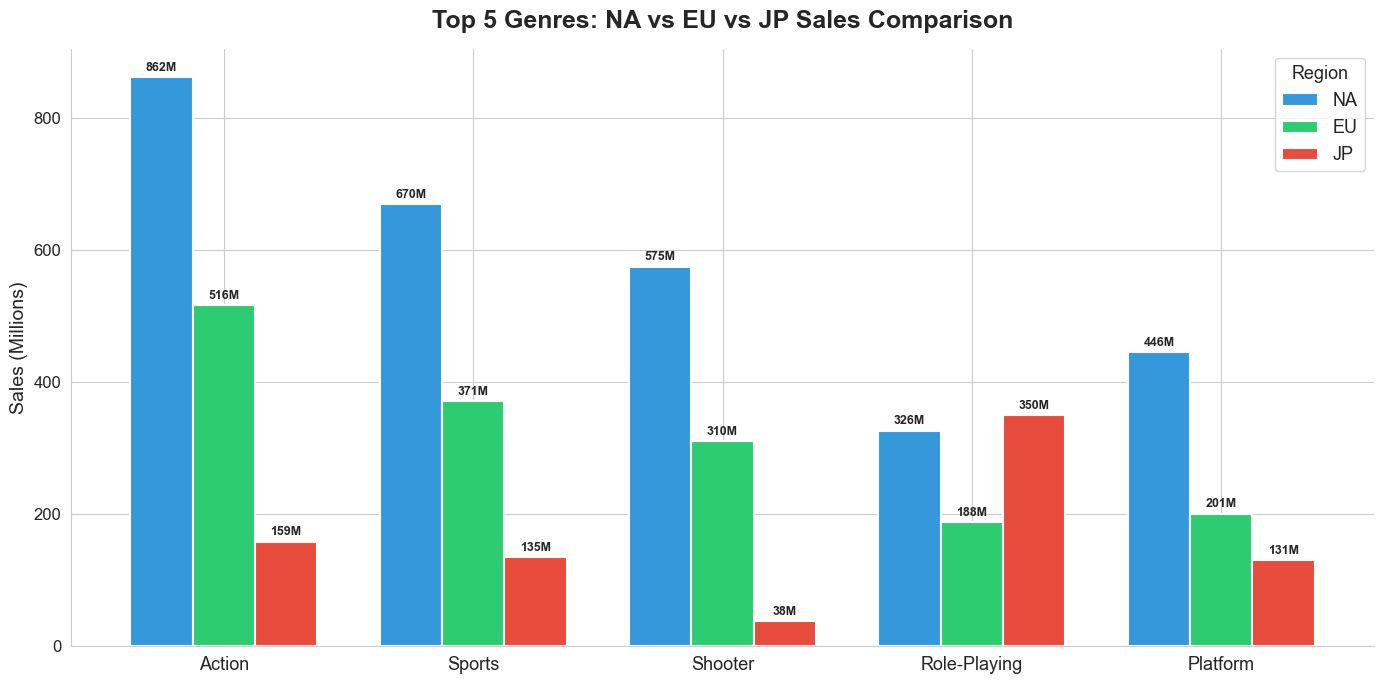

💾 Saved: chart4_top5_genres_regional.png


In [17]:
# --- BONUS 2: Grouped Bar --- Top 5 Genres across NA, EU, JP ---
top5_genres = genre_sales.head(5).index.tolist()
top5_data = genre_sales.loc[top5_genres, ['NA', 'EU', 'JP']]

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(top5_genres))
w = 0.25

bars1 = ax.bar(x - w, top5_data['NA'], w, color='#3498db', label='NA', edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x, top5_data['EU'], w, color='#2ecc71', label='EU', edgecolor='white', linewidth=1.5)
bars3 = ax.bar(x + w, top5_data['JP'], w, color='#e74c3c', label='JP', edgecolor='white', linewidth=1.5)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 5, f'{h:.0f}M',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(top5_genres, fontsize=13)
ax.set_title('Top 5 Genres: NA vs EU vs JP Sales Comparison', fontsize=18, fontweight='bold', pad=15)
ax.set_ylabel('Sales (Millions)', fontsize=14)
ax.legend(fontsize=13, title='Region', title_fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart4_top5_genres_regional.png', dpi=150, bbox_inches='tight')
plt.show()
print('\U0001f4be Saved: chart4_top5_genres_regional.png')

## 10. \U0001f4a1 4 Insights Comparing Regional Market Preferences

---

### Insight 1: NA Dominates Global Sales but JP Has Unique Tastes
North America accounts for ~49% of global sales, making it the largest market. However, **Japan has distinctly different preferences** \u2014 while NA and EU favor Action and Sports, **Japan\u2019s top genre is Role-Playing** (e.g., Final Fantasy, Pokemon). Publishers entering the Japanese market must prioritize RPG development and localization.

### Insight 2: Action Genre Is the Universal Winner (Except Japan)
**Action** is the #1 genre in both NA ($877M) and EU ($525M), but drops to #3 in Japan. Meanwhile, **Role-Playing games dominate Japan** at $352M \u2014 nearly 3x more than Action in that market. This reveals a fundamental cultural divide in gaming preferences.

### Insight 3: Nintendo Is the Undisputed Global Publisher King
**Nintendo** leads all publishers with ~$1.78B in global sales \u2014 nearly double its closest competitor. Nintendo\u2019s dominance spans all regions, driven by iconic franchises (Mario, Pokemon, Zelda) and platform exclusivity (Wii, DS). Other publishers should study Nintendo\u2019s cross-regional appeal.

### Insight 4: The Industry Peaked in 2008 and Has Been Declining
Global video game sales peaked at **~$678M in 2008**, driven by the Wii/DS era. Since then, **physical sales have declined sharply** \u2014 not because gaming shrank, but because the market shifted to **digital distribution, mobile gaming, and microtransactions** which aren\u2019t captured in this dataset. Publishers should focus on digital-first strategies.

In [18]:
print('\n' + '='*65)
print('\U0001f4cb ANALYSIS SUMMARY')
print('='*65)
print(f'Total games analyzed:      {len(df):>10,}')
print(f'Year range:                {int(df["Year"].min())} \u2192 {int(df["Year"].max())}')
print(f'Total global sales:        ${df["Global_Sales"].sum():>10,.2f}M')
print(f'NA share:                  {df["NA_Sales"].sum()/df["Global_Sales"].sum()*100:>10.1f}%')
print(f'EU share:                  {df["EU_Sales"].sum()/df["Global_Sales"].sum()*100:>10.1f}%')
print(f'JP share:                  {df["JP_Sales"].sum()/df["Global_Sales"].sum()*100:>10.1f}%')
print(f'Top genre (global):        {genre_sales.index[0]:>10}')
print(f'Top publisher:             {pub_sales.index[0]:>10}')
print(f'Top platform:              {platform_sales.index[0]:>10}')
print(f'Best-selling game:         {df.loc[df["Rank"]==1, "Name"].values[0]:>10}')
print(f'Peak year:                 {int(yearly["Global"].idxmax()):>10}')
print('='*65)
print('\u2705 Regional Video Game Analysis Complete!')


📋 ANALYSIS SUMMARY
Total games analyzed:          16,327
Year range:                1980 → 2020
Total global sales:        $  8,820.36M
NA share:                        49.1%
EU share:                        27.3%
JP share:                        14.6%
Top genre (global):            Action
Top publisher:               Nintendo
Top platform:                     PS2
Best-selling game:         Wii Sports
Peak year:                       2008
✅ Regional Video Game Analysis Complete!
